In [1]:
import geopandas as gpd
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

In [2]:
radar_id = '26'
year = '2026'
month = '02'
# day = '12'
hydrophone = 'orcasound_lab'

# Read Sound data

In [7]:
psd_df = pd.read_parquet(f'data/sound/psd/hydrophone={hydrophone}/year={year}/month={month}').sort_index().reset_index()
bb_df = pd.read_parquet(f'data/sound/broadband/hydrophone={hydrophone}/year={year}/month={month}').sort_index().reset_index()

In [8]:
print(psd_df.shape)
print(bb_df.shape)
psd_df.head()

(44863, 107)
(44863, 6)


,index,67,71,75,80,85,90,95,100,106,...,17000,18000,19000,20000,21200,22400,__index_level_0__,year,month,day
0,0,15.504925,15.117497,8.595046,11.410859,15.931487,8.432079,9.993742,8.943161,11.222028,...,9.855208,8.164799,7.347118,6.361267,6.769130,4.082400,2026-02-05 21:02:44,2026,2,5
1,1,11.663975,10.461917,15.749209,15.276044,12.234466,14.278207,16.469485,15.952275,17.110383,...,18.175060,12.759796,-1.938200,-3.543567,-5.679933,-14.199308,2026-02-05 21:02:45,2026,2,5
2,2,13.865743,16.298264,14.336754,16.650178,14.815146,13.660941,15.784561,14.917104,14.485517,...,19.677034,15.993702,-4.582960,-2.793240,-8.754143,-22.498775,2026-02-05 21:02:46,2026,2,5
3,3,9.232971,15.986811,12.340007,15.276044,16.291610,15.424398,15.548536,14.878031,17.055697,...,17.678904,9.938593,-1.462866,-2.441061,-7.032800,-14.656565,2026-02-05 21:02:47,2026,2,5
4,4,15.246067,16.130383,14.615646,15.283523,16.089604,13.633868,15.979915,16.449900,14.711978,...,22.288883,20.090726,-8.873950,-2.047458,-5.763855,-11.213346,2026-02-05 21:02:48,2026,2,5


# Read Ship Data

In [15]:
folder_path = f'{radar_id}_{year}_{month}'

gdf_ais = gpd.read_file(f'data/ship/M2/{folder_path}/{folder_path}_tracks_ais.shp')
print(gdf_ais.shape)
print(gdf_ais.columns)

gdf = gpd.read_file(f'data/ship/M2/{folder_path}/{folder_path}_tracks_radar.shp')
print(gdf.shape)
print(gdf.columns)

(19748, 38)
Index(['id_track', 'id_site', 'id_m2', 'source', 'duration', 'alarm',
       'min_speed', 'max_speed', 'avg_speed', 'curviness', 'duration_z',
       'distance', 'distance_o', 'assoc_str', 'assoc_id', 'tagged',
       'has_photos', 'detections', 'mmsi', 'imo', 'name', 'type', 'dim_a',
       'dim_b', 'dim_c', 'dim_d', 'draft', 'dest', 'eta_month', 'eta_day',
       'eta_hour', 'eta_minute', 'type_m2', 'sdate', 'stime', 'ldate', 'ltime',
       'geometry'],
      dtype='object')
(1358, 1)
Index(['geometry'], dtype='object')


In [16]:
# gdf = pd.concat([gdf_ais, gdf_radar], ignore_index=False, axis=0)
# print(gdf.shape)
# columns = gdf.columns
# print(columns)

In [17]:
gdf.head()

,geometry
0,"LINESTRING (-123.25211 48.55477, -123.25196 48..."
1,"LINESTRING (-123.2481 48.54301, -123.2471 48.5..."
2,"LINESTRING (-123.265 48.56141, -123.26497 48.5..."
3,"LINESTRING (-123.22268 48.50408, -123.22267 48..."
4,"LINESTRING (-123.21253 48.50357, -123.21248 48..."


In [18]:
# group by whether assoc_id is null or not, and calculate the min/max/avg of confidence
gdf.groupby(gdf['assoc_id'].notna()).agg({'confidence': ['min', 'max', 'mean']})

KeyError: 'assoc_id'

# Preprocessing

In [9]:
gdf['s_timestamp'] = pd.to_datetime(gdf['sdate'] + ' ' + gdf['stime'])
gdf['l_timestamp'] = pd.to_datetime(gdf['ldate'] + ' ' + gdf['ltime'])
gdf['valid'] = (gdf['confidence'] >= 0.5) | (gdf['assoc_id'].notna())


gdf = gdf[gdf['valid'] & gdf['geometry'].notna()].sort_values('s_timestamp')
print(gdf.shape)

(653, 27)


In [10]:
# Filter the GeoDataFrame for the selected time range
selected_start_time = pd.to_datetime('2026-02-07 00:00:00')
selected_end_time = pd.to_datetime('2026-02-13 23:59:59')
gdf = gdf[(gdf['s_timestamp'] >= selected_start_time) & (gdf['s_timestamp'] <= selected_end_time)].sort_values('s_timestamp')
print(gdf.shape)
print(gdf.columns)

(356, 27)
Index(['id_track', 'id_site', 'id_m2', 'source', 'duration', 'alarm',
       'min_speed', 'max_speed', 'avg_speed', 'curviness', 'duration_z',
       'distance', 'distance_o', 'assoc_str', 'assoc_id', 'tagged',
       'has_photos', 'confidence', 'detections', 'sdate', 'stime', 'ldate',
       'ltime', 'geometry', 's_timestamp', 'l_timestamp', 'valid'],
      dtype='object')


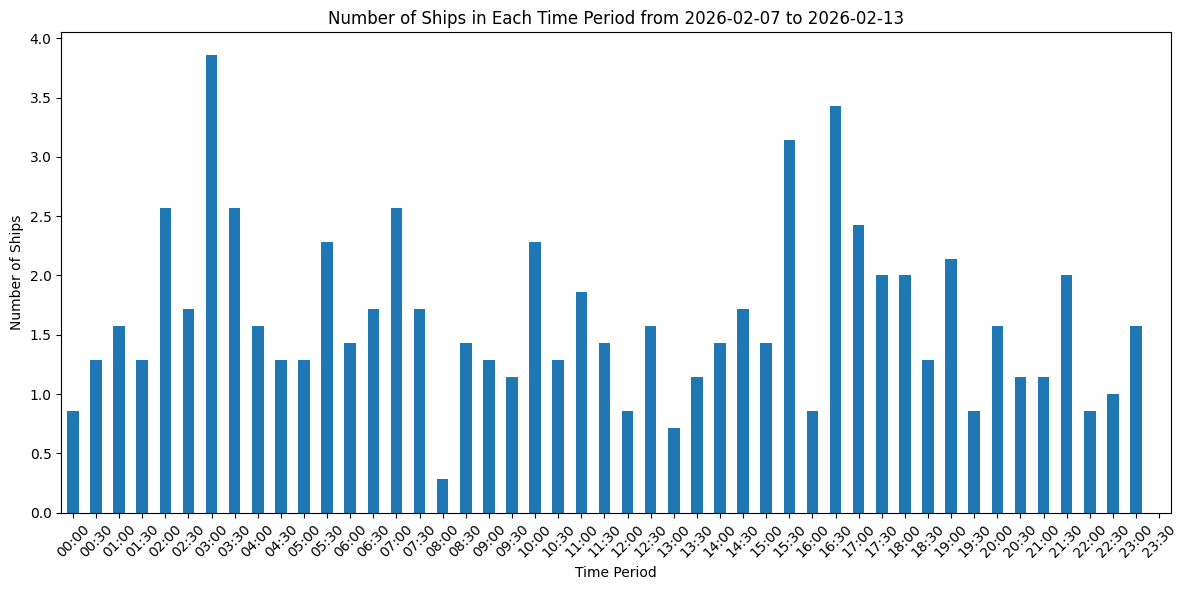

In [11]:
def plot_ship_distribution(gdf):
    '''Plot the distribution of ships based on the s_timestamp and l_timestamp. where x is the time in hours and y is the number of ships.'''
    
    gdf_temp = gdf.copy()
    for i in range(24):
        for j in range(2):
            if j == 0:
                time_str = f'{i:02d}:{j*30:02d}:00'
                time_end = f'{i:02d}:{(j+1)*30:02d}:00'
            else:
                time_str = f'{i:02d}:{j*30:02d}:00'
                time_end = f'{(i+1)%24:02d}:00:00'
            # print(time_str, time_end)
            period_start = pd.to_datetime(f'{time_str}', format='%H:%M:%S').time()
            period_end = pd.to_datetime(f'{time_end}', format='%H:%M:%S').time()
            gdf_temp[f'time_{time_str}'] = gdf_temp['s_timestamp'].dt.time.apply(lambda x: period_start <= x <= period_end) | gdf_temp['l_timestamp'].dt.time.apply(lambda x: period_start <= x <= period_end)
    # print(gdf_temp.columns)
    gdf_temp = pd.melt(gdf_temp, 
            id_vars=['id_track', 'sdate'], 
            value_vars=[col for col in gdf_temp.columns if col.startswith('time_')], 
            var_name='time_period', 
            value_name='present')

    # make time_period to be datetime.time type
    gdf_temp['time_period'] = gdf_temp['time_period'].apply(lambda x: pd.to_datetime(x.split('_')[1], format='%H:%M:%S').time().strftime('%H:%M'))
    gdf_cube = gdf_temp.groupby(['sdate', 'time_period'])[['present']].sum()
    
    # plot the number of ships in each time period
    plt.figure(figsize=(12, 6))
    gdf_cube.groupby('time_period')['present'].mean().plot(kind='bar')
    plt.xlabel('Time Period')
    plt.ylabel('Number of Ships')
    plt.title(f'Number of Ships in Each Time Period from {selected_start_time.date()} to {selected_end_time.date()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

plot_ship_distribution(gdf)

In [12]:
def count_avg_ships_perday(gdf):
    '''Count the average number of ships per day based on the s_timestamp'''
    gdf_temp = gdf.copy()
    avg_per_day = gdf_temp.groupby(gdf_temp['s_timestamp'].dt.date)['id_track'].nunique().mean()
    return avg_per_day

avg_ships_per_day = count_avg_ships_perday(gdf)
print(f'Average number of ships per day: {avg_ships_per_day:.1f}')

Average number of ships per day: 50.9


In [13]:
from shapely.geometry import Point


class ShipMetricsCalculator:
    def __init__(self, gdf, gdf_ais, bb_df, psd_df, comm_range_min=500, comm_range_max=15000):
        self.gdf = gdf
        self.gdf_ais = gdf_ais
        self.bb_df = bb_df.sort_index()
        self.psd_df = psd_df.sort_index()
        self.comm_range = [comm_range_min, comm_range_max]
        self.hydrophone_metadata = {'coordinates': [-123.1735774, 48.5583362], # Orcasound_lab coordinates
                                    'crs': {'properties': {'name': 'EPSG:4326'}, 
                                            'type': 'name'}, 'type': 'Point'}
    def get_ship_type(self, type_code):
        '''Map the ship type code to a more general category'''
        if np.isnan(type_code):
            return None
        elif type_code <= 0:
            return '-'
        elif type_code <=19:
            return 'reserved'
        elif type_code <= 29:
            return 'wing_in_ground'
        elif type_code <= 30:
            return 'fishing'
        elif type_code <= 32:
            return 'towing'
        elif type_code == 33:
            return 'dredging_or_underwater_operations'
        elif type_code == 34:
            return 'diving_operations'
        elif type_code == 35:
            return 'military_operations'
        elif type_code == 36:
            return 'sailing'
        elif type_code == 37:
            return 'pleasure_craft'
        elif type_code <= 39:        
            return 'reserved'
        elif type_code <= 49:
            return 'high_speed_craft'
        elif type_code == 50:
            return 'pilot_vessel'
        elif type_code == 51:
            return 'search_and_rescue_vessel'
        elif type_code == 52:
            return 'tug'
        elif type_code == 53:
            return 'port_tender'
        elif type_code == 54:
            return 'anti_pollution_equipment'
        elif type_code == 55:
            return 'law_enforcement'
        elif type_code <= 57:
            return 'spare_local_vessel'
        elif type_code == 58:
            return 'medical_transport'
        elif type_code == 59:
            return 'noncombatant_ship'
        elif type_code <= 69:
            return 'passenger'
        elif type_code <= 79:
            return 'cargo'
        elif type_code <= 89:
            return 'tanker'
        elif type_code <= 99:
            return 'other_type'
        else:
            return 'unknown'
            

    def get_ais_metadata(self, gdf, gdf_ais):
        '''Extract AIS metadata'''
        
        gdf_temp = pd.merge(gdf, gdf_ais, left_on='assoc_id', right_on='id_track', how='left')
        # ais_id = gdf.loc[gdf['id_track'] == ship_id, 'assoc_id'].values[0]
        gdf_temp = gdf_temp[['mmsi', 'imo', 'name', 'draft', 'type']]

        gdf_temp['mmsi'] = gdf_temp['mmsi'].astype(str).replace('.0', '')
        gdf_temp['imo'] = gdf_temp['imo'].astype(str).replace('.0', '')
        gdf_temp['type_id'] = gdf_temp['type'].copy()
        gdf_temp['type'] = [self.get_ship_type(x) for x in gdf_temp['type_id'].values]
        
        return gdf_temp

    def get_isolate_flag(self, gdf, s_timestamp, l_timestamp, id_track):
        '''Determine if a ship is an isolate ship, which means it is the only ship present during its presence time.'''
        mask = (
            (gdf['s_timestamp'].between(s_timestamp, l_timestamp) | (gdf['l_timestamp'].between(s_timestamp, l_timestamp)))
            & (gdf['id_track'] != id_track)
            )

        return sum(mask) == 0


    def prepare_sound_metrics(self):
        ''' Prepare the sound metrics by calculating the mean PSD in the communication frequency range and adding the broadband metric'''
        sound_df = self.psd_df.copy()
        sound_df['bb'] = self.bb_df['0']

        comm_min, comm_max = self.comm_range
        # select comm_min - comm_max Hz
        central_hz = [c for c in sound_df.columns
                    if c.isdigit() and comm_min <= int(c) <= comm_max]
        psd_selected = sound_df[central_hz]

        # bandwidth for 1/12 octave
        delta_f = np.array([int(hz) * (2**(1/24) - 2**(-1/24)) for hz in central_hz])
        
        # convert to linear
        psd_linear = 10**(psd_selected / 10)

        # integrate
        power = np.sum(psd_linear * delta_f, axis=1)

        # broadband level
        sound_df['comm_bb'] = 10 * np.log10(power)

        self._sound_df = sound_df[['index', 'comm_bb', 'bb']]

    def get_acoustic_metrics(self, s_time, l_time):
        '''Calculate the average PSD during the presence of each ship using vectorized operations'''
        times = self._sound_df['index'].between(s_time, l_time)
        sub = self._sound_df[times]
        
        comm_bb = sub['comm_bb']
        bb = sub['bb']

        return [
            comm_bb.mean(),
            comm_bb.quantile(0.95),
            comm_bb.quantile(0.75),
            comm_bb.quantile(0.5),
            bb.mean(),
            bb.quantile(0.95),
            bb.quantile(0.5),
            np.array(comm_bb.tolist()),
            np.array(bb.tolist())
        ]
  

    def get_distance_to_hydrophone(self, gdf, hydrophone_metadata, target_crs="EPSG:32610"):
        '''Calculate the distance from each ship to the hydrophone'''
        # Assuming the hydrophone location is given as a Point geometry
        pt_lon, pt_lat = hydrophone_metadata['coordinates'][0], hydrophone_metadata['coordinates'][1]
        point_gs = gpd.GeoSeries([Point(pt_lon, pt_lat)], crs="EPSG:4326") #lat/lon

        gdf_projected = gdf['geometry'].to_crs(target_crs)
        target_pt = point_gs.to_crs(target_crs).iloc[0]
        return gdf_projected.distance(target_pt)
        

    def get_all_ship_metrics(self):
        '''Calculate all ship metrics during the presence of each ship'''
        
        
        gdf_output = self.gdf[['id_track', 's_timestamp', 'l_timestamp', 'duration',
                               'avg_speed', 'max_speed', 'min_speed',
                               'distance', 'curviness', 'confidence', 'geometry']].reset_index(drop=True)
        
        gdf_output['min_dist'] = self.get_distance_to_hydrophone(gdf_output, hydrophone_metadata=self.hydrophone_metadata)
        gdf_output['is_isolated'] = gdf_output.apply(lambda x: 
                                        self.get_isolate_flag(self.gdf,
                                            x['s_timestamp'], 
                                            l_timestamp=x['l_timestamp'],
                                            id_track=x['id_track']
                                            ), 
                                        axis=1
                                    )
        gdf_output[['mmsi', 'imo', 'name', 'draft', 'type_id', 'type']] = self.get_ais_metadata(self.gdf, self.gdf_ais)
        
        self.prepare_sound_metrics()
        acoustic_metrics = [
            self.get_acoustic_metrics(s, l)
            for s, l in zip(gdf_output['s_timestamp'], gdf_output['l_timestamp'])
        ]

        acoustic_metrics_cols = ['comm_avg', 'comm_95th', 'comm_75th', 'comm_50th',
                'bb_avg', 'bb_95th', 'bb_50th',
                'comm_bb_series', 'bb_series']

        gdf_output[acoustic_metrics_cols] = pd.DataFrame(acoustic_metrics, index=gdf_output.index)

        return gdf_output

    

In [14]:
MetricsCalculator = ShipMetricsCalculator(gdf, gdf_ais, bb_df, psd_df)
ship_metrics = MetricsCalculator.get_all_ship_metrics()
ship_metrics

,id_track,s_timestamp,l_timestamp,duration,avg_speed,max_speed,min_speed,distance,curviness,confidence,...,type,comm_avg,comm_95th,comm_75th,comm_50th,bb_avg,bb_95th,bb_50th,comm_bb_series,bb_series
0,49079482,2026-02-07 00:56:12,2026-02-07 01:26:49,1837.0,14.794485,15.80,11.1,14.232177,1.020883,0.997881,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
1,49079710,2026-02-07 01:09:17,2026-02-07 01:49:12,2395.0,10.812845,13.80,8.6,13.776899,1.032471,0.998177,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
2,49079821,2026-02-07 01:21:54,2026-02-07 01:22:52,58.0,15.500000,16.20,12.7,0.454904,1.005523,0.886536,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
3,49079919,2026-02-07 01:34:17,2026-02-07 01:34:39,22.0,21.000000,21.00,21.0,0.137715,1.009824,0.864900,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
4,49079972,2026-02-07 01:40:28,2026-02-07 02:18:07,2259.0,11.839606,13.50,9.1,14.113741,1.028541,0.997460,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,[],[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
351,49184777,2026-02-13 22:20:17,2026-02-13 23:30:49,4232.0,11.013865,12.90,0.6,25.505595,1.114808,0.997563,...,NaN,68.524960,70.623209,69.979865,67.972417,9.084570,21.788272,6.016376,"[68.57954597591977, 68.63444360660532, 68.6193...","[8.700355376604165, 8.995793267205727, 9.15484..."
352,49185366,2026-02-13 23:33:22,2026-02-13 23:43:34,612.0,16.915053,17.89,15.2,5.398564,1.015114,0.988509,...,NaN,69.089247,70.511350,70.127338,68.955686,10.837394,21.088105,8.989600,"[67.93024797025777, 67.71952474942086, 67.8477...","[3.414473543027441, 2.328425808938718, 3.06717..."
353,49185432,2026-02-13 23:41:37,2026-02-13 23:42:16,39.0,6.733333,8.10,2.6,0.169308,1.003579,0.923027,...,NaN,70.310461,70.515187,70.390320,70.312605,18.705720,19.850175,18.617417,"[70.37696861309948, 70.12733760783065, 70.3542...","[18.73344963837772, 17.01278027136067, 18.4478..."
354,49185458,2026-02-13 23:43:54,2026-02-13 23:57:15,801.0,18.476486,19.60,15.6,7.549467,1.016283,0.981496,...,NaN,69.632791,70.591950,70.191416,69.637569,15.924532,22.821942,15.702229,"[70.31870376735364, 70.51299659495089, 70.3916...","[20.79855766615141, 21.53309315897731, 20.7838..."


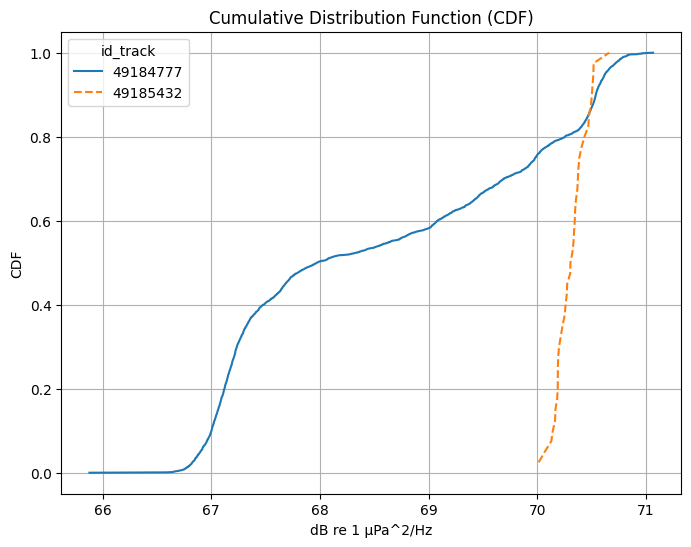

In [15]:
ind1, ind2 = 351, 353

def plot_cdf(ind1, ind2=None):
    '''Plot the CDF of a given series'''
    series1 = ship_metrics.iloc[ind1]['comm_bb_series']
    

    sorted_series = np.sort(series1)

    cdf = np.arange(1, len(sorted_series)+1) / len(sorted_series)
    
    plt.figure(figsize=(8, 6))
    plt.plot(sorted_series, cdf, linestyle='-')
    if ind2 is not None:
        series2 = ship_metrics.iloc[ind2]['comm_bb_series']
        sorted_series2 = np.sort(series2)
        cdf2 = np.arange(1, len(sorted_series2)+1) / len(sorted_series2)
        plt.plot(sorted_series2, cdf2, linestyle='--')
        plt.legend(ship_metrics.iloc[[ind1, ind2]]['id_track'].values.astype(str), title='id_track')
    plt.xlabel('dB re 1 μPa^2/Hz')
    plt.ylabel('CDF')
    plt.title('Cumulative Distribution Function (CDF)')
    plt.grid()
    plt.show()


plot_cdf(ind1, ind2)

In [22]:
psd_df_temp = psd_df.copy()

for id_track in gdf['id_track'].unique():
    s_time = gdf.loc[gdf['id_track'] == id_track, 's_timestamp'].values[0]
    l_time = gdf.loc[gdf['id_track'] == id_track, 'l_timestamp'].values[0]
    psd_df_temp['track_' + str(id_track)] = psd_df_temp['index'].between(s_time, l_time)

psd_df_temp['ship_presence'] = psd_df_temp[[col for col in psd_df_temp.columns if col.startswith('track_')]].any(axis=1)
psd_df_temp

/var/folders/1s/89d5t8ln1xd3m_vytz6l1v2w0000gn/T/ipykernel_67509/1799193361.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  psd_df_temp['track_' + str(id_track)] = psd_df_temp['index'].between(s_time, l_time)
/var/folders/1s/89d5t8ln1xd3m_vytz6l1v2w0000gn/T/ipykernel_67509/1799193361.py:6: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  psd_df_temp['track_' + str(id_track)] = psd_df_temp['index'].between(s_time, l_time)
/var/folders/1s/89d5t8ln1xd3m_vytz6l1v2w0000gn/T/ipykernel_67509/1799193361.py:6: PerformanceWarning: DataFr

,index,67,71,75,80,85,90,95,100,106,...,track_49183042,track_49183177,track_49183236,track_49183268,track_49184777,track_49185366,track_49185432,track_49185458,track_49185466,ship_presence
0,2026-02-07 12:18:13,17.000665,19.294618,20.197513,19.322835,18.659616,21.115209,20.999857,22.689917,19.256854,...,False,False,False,False,False,False,False,False,False,True
1,2026-02-07 12:18:14,19.467176,19.457936,21.374846,21.176110,22.079493,22.903928,21.202620,23.469553,20.831801,...,False,False,False,False,False,False,False,False,False,True
2,2026-02-07 12:18:15,19.811217,19.420876,21.221506,21.924292,21.787503,23.446219,22.431197,22.463962,21.759176,...,False,False,False,False,False,False,False,False,False,True
3,2026-02-07 12:18:16,18.480414,18.302718,20.319762,23.340436,22.431197,22.981302,22.731241,22.208427,20.720595,...,False,False,False,False,False,False,False,False,False,True
4,2026-02-07 12:18:17,18.840161,18.418112,19.089674,21.330246,21.882432,22.463962,22.962795,22.295555,21.965951,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583190,2026-02-13 23:59:51,23.402299,23.437453,24.555164,23.048825,21.605313,21.673635,22.857171,22.972053,21.088430,...,False,False,False,False,False,False,False,False,False,False
583191,2026-02-13 23:59:52,24.687814,22.781832,24.454329,24.482889,23.130983,22.134015,21.540087,22.358677,20.583616,...,False,False,False,False,False,False,False,False,False,False
583192,2026-02-13 23:59:53,24.280974,24.344413,23.758871,23.112793,23.495728,22.866543,22.872785,21.141906,20.922096,...,False,False,False,False,False,False,False,False,False,False
583193,2026-02-13 23:59:54,23.820632,24.063378,23.736302,24.014275,22.522628,22.437760,22.574446,21.882432,21.576384,...,False,False,False,False,False,False,False,False,False,False


## Plot C: Ship-Free Fraction by Window Length

In [ ]:
window_days = ship_free_df["window_days"].to_list()
ship_free_pct = [v * 100 for v in ship_free_df["ship_free_pct"].to_list()]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar([str(d) for d in window_days], ship_free_pct)
ax.bar_label(bars, fmt='%.1f%%', padding=3)
ax.set_title("Ship-Free Fraction by Analysis Window (Method 1)")
ax.set_xlabel("Window Length (days)")
ax.set_ylabel("Ship-Free Time (%)")
ax.set_ylim(0, 100)
plt.tight_layout()
plt.show()

## Plot D: Ship Presence by Hour of Day

In [ ]:
hourly = (
    presence_mask
    .with_columns(pl.col("ts").dt.hour().alias("hour"))
    .group_by("hour")
    .agg(pl.col("ship_present").mean().alias("fraction"))
    .sort("hour")
)

hours = hourly["hour"].to_list()
fractions = hourly["fraction"].to_list()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(hours, fractions)
ax.set_xticks(range(24))
ax.set_xticklabels([str(h) for h in range(24)])
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(xmax=1))
ax.set_title("Ship Presence by Hour of Day (Feb 7–13, 2026)")
ax.set_xlabel("Hour (UTC)")
ax.set_ylabel("Fraction of Seconds with Ship Present")
plt.tight_layout()
plt.show()